    frame_index  timestamp_seconds      ball_x       ball_y    ball_size  \
0             0           0.000000  888.089630  1500.926971  2319.650550   
1             1           0.016703  888.088928  1500.929047  2319.992317   
2             2           0.033407  888.091095  1500.927917  2319.722090   
3             3           0.050110  888.093231  1500.928131  2320.065307   
4             4           0.066814  888.094513  1500.928986  2319.515752   
5             5           0.083517  888.092163  1500.929352  2319.261158   
6             6           0.100221  888.092529  1500.932144  2318.473470   
7             7           0.116924  889.239410  1473.435623  2373.200045   
8             8           0.133628  891.032471  1446.469727  2429.134910   
9             9           0.150331  891.025909  1446.480118  2428.618739   
10           10           0.167035  892.669678  1416.845993  2222.681134   
11           11           0.183738  893.626740  1387.642426  2507.932895   
12          

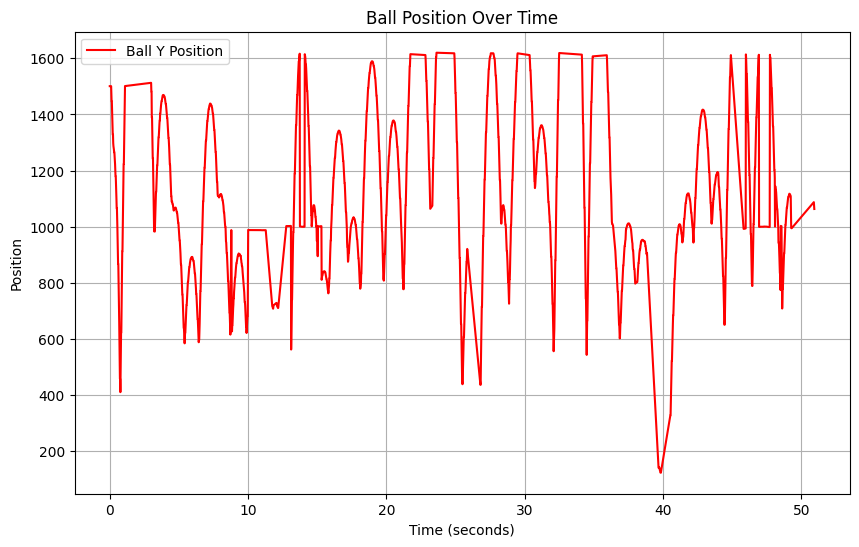

In [16]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# Path to the JSONL file
file_path = "frame_results.jsonl"

# Load the JSONL file into a pandas DataFrame
data = []
with open(file_path, 'r') as f:
    for line in f:
        record = json.loads(line)
        # Extract relevant fields
        ball_detection = record.get("ball_detection", None)
        action_detections = record.get("action_detections", None)  # Corrected key name
        
        # Process ball detection
        if ball_detection is not None and "bbox" in ball_detection:
            ball_bbox = ball_detection["bbox"]
            x = (ball_bbox["x1"] + ball_bbox["x2"]) / 2
            y = 1800-((ball_bbox["y1"] + ball_bbox["y2"]) / 2) # invert
            object_size = (ball_bbox["x2"] - ball_bbox["x1"]) * (ball_bbox["y2"] - ball_bbox["y1"])
            ball_confidence = ball_detection.get("confidence", None)
        else:
            x, y, ball_confidence = None, None, None
        
        # Process action detections
        if action_detections:
            # Find the entry with the highest confidence
            best_action = max(action_detections, key=lambda action: action.get("confidence", 0))
            action_class_id = best_action.get("class_id", None)
        else:
            action_class_id = None

        # Append the data
        data.append({
            "frame_index": record["frame_index"],
            "timestamp_seconds": record["timestamp_seconds"],
            "ball_x": x,
            "ball_y": y,
            "ball_size": object_size,
            "ball_confidence": ball_confidence,
            "action_class_id": action_class_id
        })

# Create a DataFrame
df = pd.DataFrame(data)

# Filter out rows where ball confidence is below 0.75 and for missing ball positions
df = df[df["ball_confidence"] > 0.75]
df = df.dropna(subset=['ball_x', 'ball_y'])

# Display the DataFrame
print(df.head(20))

plt.figure(figsize=(10, 6))
plt.plot(df['timestamp_seconds'], df['ball_y'], label='Ball Y Position', color='red')
plt.xlabel('Time (seconds)')
plt.ylabel('Position')
plt.title('Ball Position Over Time')
plt.legend()
plt.grid(True)
plt.show()

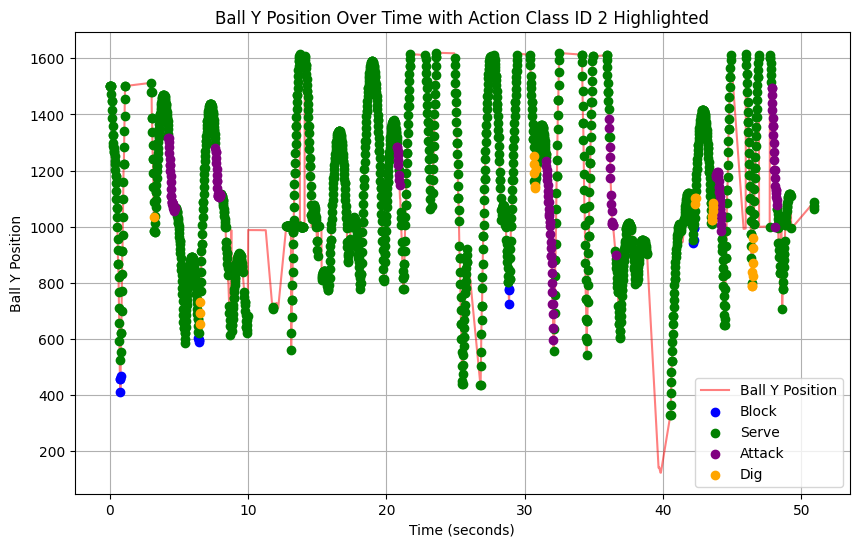

In [17]:
plt.figure(figsize=(10, 6))

# Plot all ball_y positions over time
plt.plot(df['timestamp_seconds'], df['ball_y'], label='Ball Y Position', color='red', alpha=0.5)

# Filter points with action_class_id == 2
action_class_2 = df[df['action_class_id'] == 2]
action_class_0 = df[df['action_class_id'] == 0]
action_class_1 = df[df['action_class_id'] == 1]
action_class_3 = df[df['action_class_id'] == 3]

# Plot points with action_class_id == 2
plt.scatter(action_class_2['timestamp_seconds'], action_class_2['ball_y'], color='blue', label='Block', zorder=5)
plt.scatter(action_class_0['timestamp_seconds'], action_class_0['ball_y'], color='green', label='Serve', zorder=5)
plt.scatter(action_class_1['timestamp_seconds'], action_class_1['ball_y'], color='purple', label='Attack', zorder=5)
plt.scatter(action_class_3['timestamp_seconds'], action_class_3['ball_y'], color='orange', label='Dig', zorder=5)

# Add labels, title, and legend
plt.xlabel('Time (seconds)')
plt.ylabel('Ball Y Position')
plt.title('Ball Y Position Over Time with Action Class ID 2 Highlighted')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

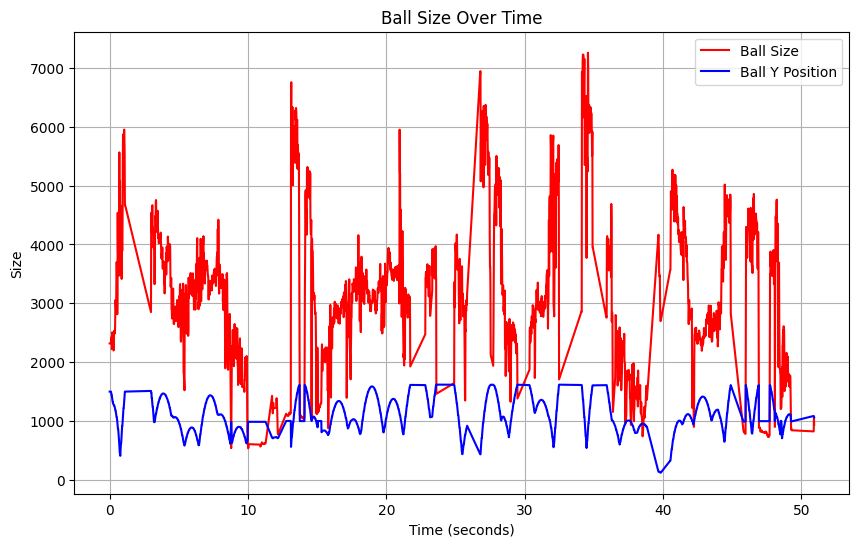

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(df['timestamp_seconds'], df['ball_size'], label='Ball Size', color='red')
plt.plot(df['timestamp_seconds'], df['ball_y'], label='Ball Y Position', color='blue')

plt.xlabel('Time (seconds)')
plt.ylabel('Size')
plt.title('Ball Size Over Time')
plt.legend()
plt.grid(True)
plt.show()

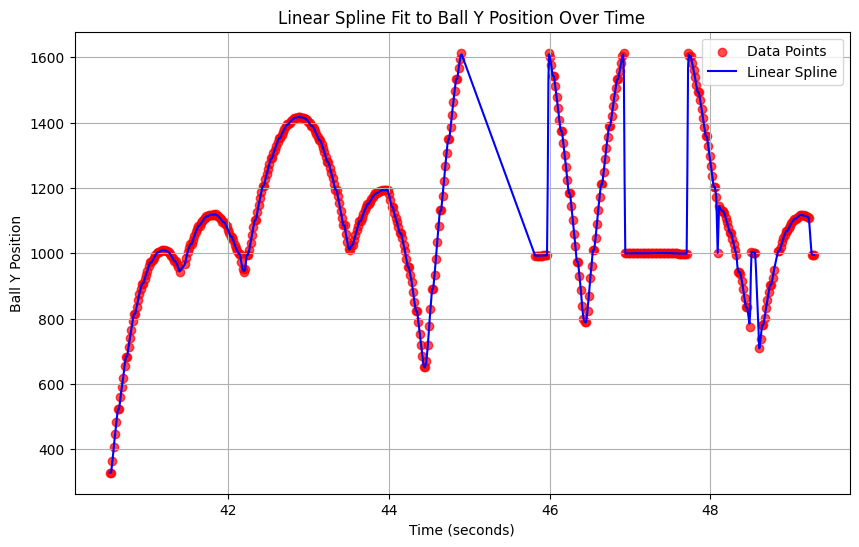

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Define the time interval (edit as needed)
start_time = 40  # Start time in seconds
end_time = 50    # End time in seconds

# Filter the DataFrame for the specified time interval
interval_df = df[(df['timestamp_seconds'] >= start_time) & (df['timestamp_seconds'] <= end_time)]

# Extract the x (time) and y (ball_y) values
x = interval_df['timestamp_seconds'].values
y = interval_df['ball_y'].values

# Fit a quadratic spline to the data
spline = make_interp_spline(x, y, k=1)  # k=2 for quadratic spline
x_smooth = np.linspace(x.min(), x.max(), 1000)  # Generate smooth x values
y_smooth = spline(x_smooth)  # Evaluate the spline at the smooth x values

# Plot the scatterplot and the spline
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Data Points', alpha=0.7)
plt.plot(x_smooth, y_smooth, color='blue', label='Linear Spline')
plt.xlabel('Time (seconds)')
plt.ylabel('Ball Y Position')
plt.title('Linear Spline Fit to Ball Y Position Over Time')
plt.legend()
plt.grid(True)
plt.show()

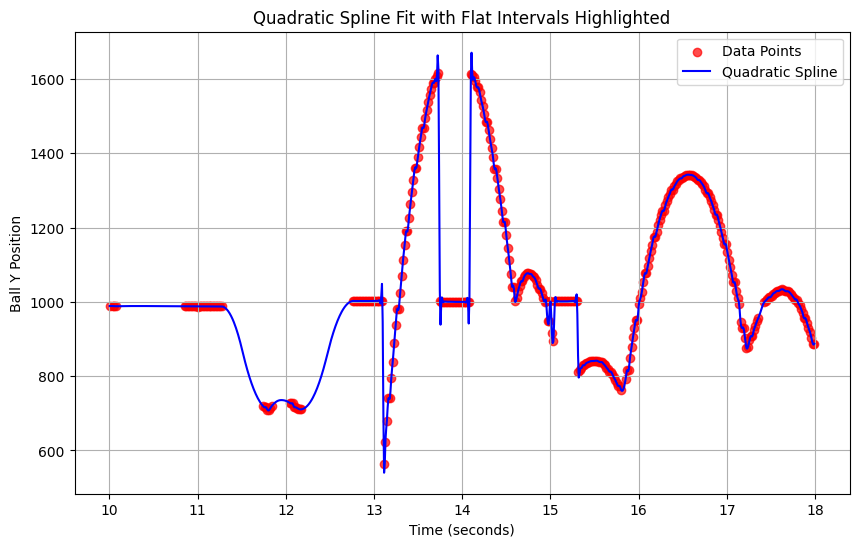

    frame_index  timestamp_seconds      ball_x       ball_y    ball_size  \
0             0           0.000000  888.089630  1500.926971  2319.650550   
1             1           0.016703  888.088928  1500.929047  2319.992317   
2             2           0.033407  888.091095  1500.927917  2319.722090   
3             3           0.050110  888.093231  1500.928131  2320.065307   
4             4           0.066814  888.094513  1500.928986  2319.515752   
5             5           0.083517  888.092163  1500.929352  2319.261158   
6             6           0.100221  888.092529  1500.932144  2318.473470   
7             7           0.116924  889.239410  1473.435623  2373.200045   
8             8           0.133628  891.032471  1446.469727  2429.134910   
9             9           0.150331  891.025909  1446.480118  2428.618739   
10           10           0.167035  892.669678  1416.845993  2222.681134   
11           11           0.183738  893.626740  1387.642426  2507.932895   
12          

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Define the time interval (edit as needed)
start_time = 10  # Start time in seconds
end_time = 18    # End time in seconds

# Filter the DataFrame for the specified time interval
interval_df = df[(df['timestamp_seconds'] >= start_time) & (df['timestamp_seconds'] <= end_time)]

# Extract the x (time) and y (ball_y) values
x = interval_df['timestamp_seconds'].values
y = interval_df['ball_y'].values

# Fit a quadratic spline to the data
spline = make_interp_spline(x, y, k=2)  # k=2 for quadratic spline
x_smooth = np.linspace(x.min(), x.max(), 1000)  # Generate smooth x values
y_smooth = spline(x_smooth)  # Evaluate the spline at the smooth x values

# Calculate the derivative of the spline
spline_derivative = spline.derivative()
y_derivative = spline_derivative(x_smooth)

# Find points where the slope is nearly 0
threshold = 0.01  # Define a threshold for "nearly 0"
flat_indices = np.where(np.abs(y_derivative) < threshold)[0]

# Find the start and end of flat intervals
flat_intervals = []
start = None
for i in range(len(flat_indices) - 1):
    if start is None:
        start = flat_indices[i]
    if flat_indices[i + 1] != flat_indices[i] + 1:
        flat_intervals.append((x_smooth[start], x_smooth[flat_indices[i]]))
        start = None
if start is not None:
    flat_intervals.append((x_smooth[start], x_smooth[flat_indices[-1]]))

# Remove points within flat intervals
for interval in flat_intervals:
    df = df[~((df['timestamp_seconds'] >= interval[0]) & (df['timestamp_seconds'] <= interval[1]))]

# Plot the scatterplot and the spline
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Data Points', alpha=0.7)
plt.plot(x_smooth, y_smooth, color='blue', label='Quadratic Spline')

# Highlight flat intervals
for interval in flat_intervals:
    plt.axvspan(interval[0], interval[1], color='yellow', alpha=0.3, label='Flat Interval')

plt.xlabel('Time (seconds)')
plt.ylabel('Ball Y Position')
plt.title('Quadratic Spline Fit with Flat Intervals Highlighted')
plt.legend()
plt.grid(True)
plt.show()

# Display the filtered DataFrame
print(df.head(20))

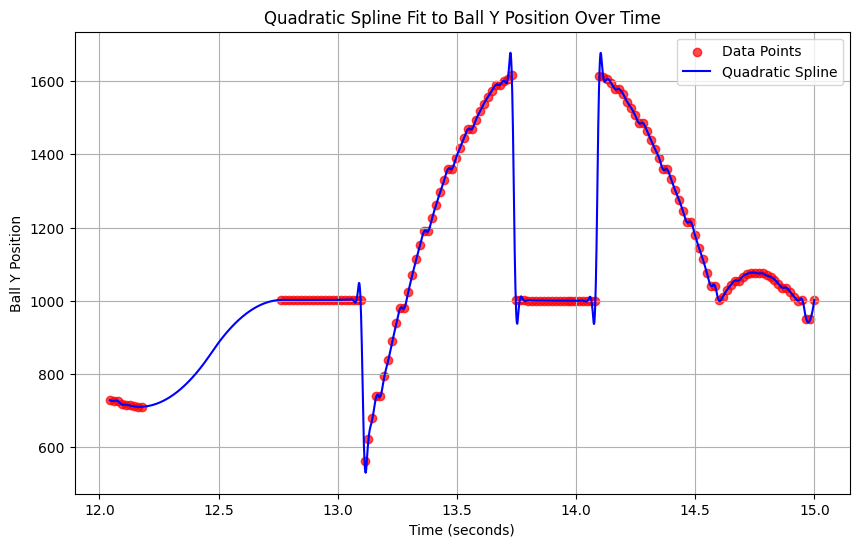

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Define the time interval (edit as needed)
start_time = 12  # Start time in seconds
end_time = 15    # End time in seconds

# Filter the DataFrame for the specified time interval
interval_df = df[(df['timestamp_seconds'] >= start_time) & (df['timestamp_seconds'] <= end_time)]

# Extract the x (time) and y (ball_y) values
x = interval_df['timestamp_seconds'].values
y = interval_df['ball_y'].values

# Fit a quadratic spline to the data
spline = make_interp_spline(x, y, k=2)  # k=2 for quadratic spline
x_smooth = np.linspace(x.min(), x.max(), 2000)  # Generate smooth x values
y_smooth = spline(x_smooth)  # Evaluate the spline at the smooth x values

# Plot the scatterplot and the spline
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Data Points', alpha=0.7)
plt.plot(x_smooth, y_smooth, color='blue', label='Quadratic Spline')
plt.xlabel('Time (seconds)')
plt.ylabel('Ball Y Position')
plt.title('Quadratic Spline Fit to Ball Y Position Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# Function to get y position at a specific time on the spline
def get_y_at_time(spline, time):
    return spline(time)

# Example usage
input_time = float(input("Enter the time (in seconds): "))
if x.min() <= input_time <= x.max():
    y_at_time = get_y_at_time(spline, input_time)
    print(f"The y position at time {input_time} seconds is {y_at_time}.")
else:
    print("The input time is out of the range of the spline.")

The y position at time 45.5 seconds is 1206.575022723473.
